In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.colors import BoundaryNorm
from pathlib import Path
from scipy import stats

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

um.WarningSuppress()

MEANS_DIR = Path("../Data/Models/Monthly_Means")
TS_DIR = Path("../Data/Models/Timeseries")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Fig. S9 - Vegetation Feedback on Surface Temperature

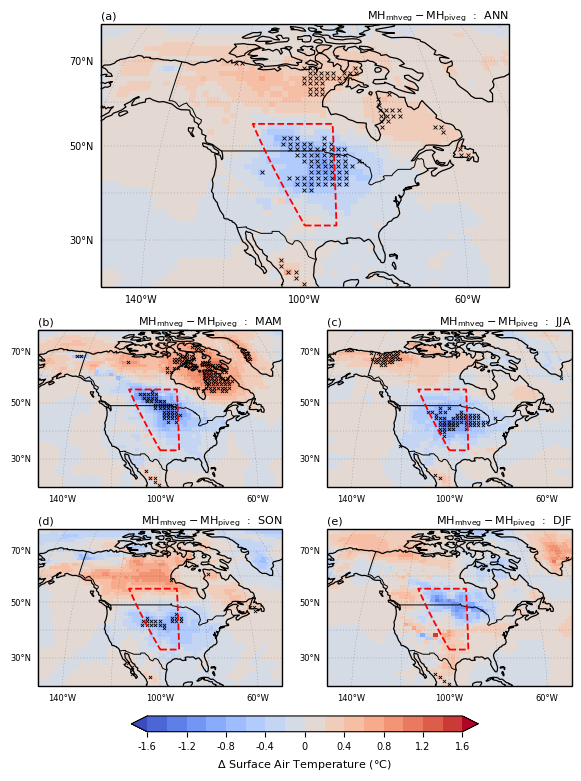

In [ ]:
# ----------------------------------------------------------------------------
# Load Data and set parameters
# ----------------------------------------------------------------------------

MH_MHVEG = um.importUMData(MEANS_DIR / "mh_mhveg_monthly_means.nc")
MH_PIVEG = um.importUMData(MEANS_DIR / "mh_piveg_monthly_means.nc")

# Null spread: raw monthly tas from the MH production run (u-dd727), in Celsius.
MH_var = xr.load_dataarray(TS_DIR / "MH" / "tas_197001-204912.nc", decode_times=False) - 273.15

LAND = um.importUMData("../Data/Models/lsm_um13.2.nc") == 1
GP = umplt.umRegion("GP")
GP_MASK = umplt.umRegionMask("GP", MH_MHVEG.longitude, MH_MHVEG.latitude)

N_YEARS = 30            # years averaged in each of A and B
ALPHA   = 0.05          # two-sided significance level
VMAX    = 1.6           # colour limit (°C)
CMAP    = cm.coolwarm

PANELS = {"ANN": np.arange(12), "MAM": [2, 3, 4], "JJA": [5, 6, 7],
          "SON": [8, 9, 10],    "DJF": [11, 0, 1]}

# ----------------------------------------------------------------------------
# Significance against internal variability
# ----------------------------------------------------------------------------

def _seasonal_per_year(da, months):
    n_years = da.sizes["time"] // 12
    da = da.assign_coords(year=("time", np.repeat(np.arange(n_years), 12)),
                          month=("time", np.tile(np.arange(12), n_years)))
    ym = da.set_index(time=["year", "month"]).unstack("time")    
    return ym.isel(month=months).mean("month").transpose("year", ...)


def significant(obs, months):
    sea = _seasonal_per_year(MH_var, months)
    Y = sea.values                                    

    Ya = Y - Y.mean(axis=0)                            # lag-1 autocorrelation
    den = (Ya ** 2).sum(axis=0)
    with np.errstate(invalid="ignore", divide="ignore"):
        r1 = np.where(den > 0, (Ya[:-1] * Ya[1:]).sum(axis=0) / den, 0.0)
    r1 = np.clip(np.nan_to_num(r1), 0.0, 0.99)          

    f = (1.0 - r1) / (1.0 + r1)                         # effective-sample-size factor
    with np.errstate(invalid="ignore", divide="ignore"):
        se = Y.std(axis=0, ddof=1) * np.sqrt(2.0 / (N_YEARS * f))
        p  = 2.0 * stats.t.sf(np.abs(obs.values / se),
                              np.maximum(Y.shape[0] * f - 1.0, 1.0))

    dims = sea.dims[1:]                                
    sig  = xr.DataArray(p <= ALPHA, dims=dims,          
                        coords={d: sea.coords[d] for d in dims})
    return sig & LAND

# ----------------------------------------------------------------------------
# Figure: large ANN panel on top, 2x2 seasonal grid below
# ----------------------------------------------------------------------------

fig = plt.figure(figsize=(5.7, 7.7), constrained_layout=True)
gs = GridSpec(3, 2, figure=fig, height_ratios=[1.5, 1, 1])
SLOTS = [gs[0, :], gs[1, 0], gs[1, 1], gs[2, 0], gs[2, 1]]
norm = BoundaryNorm(np.linspace(-VMAX, VMAX, 17), CMAP.N, extend="both")
axes = []

for k, (season, idx) in enumerate(PANELS.items()):
    obs = MH_MHVEG["tas"].isel(time=idx).mean("time") - MH_PIVEG["tas"].isel(time=idx).mean("time")

    ax = fig.add_subplot(SLOTS[k], projection=ccrs.Robinson(central_longitude=-100))
    axes.append(ax)

    umplt.plotBaseMap(ax, [-150, -50, 20, 80], coastlw=0.9, bordercol="black",
                      borderlw=0.7, spinelw=1.0)
    umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50, 70],
                   xlines=[-40, -80, -120, -160], ylines=[20, 40, 60],
                   labelsize=6 if k else 7, lw=0.15)

    mesh = ax.pcolormesh(obs.longitude, obs.latitude, obs, cmap=CMAP, norm=norm,
                         transform=ccrs.PlateCarree(), zorder=0)

    LON, LAT = np.meshgrid(obs.longitude, obs.latitude)
    m = significant(obs, idx).values
    ax.scatter(LON[m], LAT[m], s=8 if k == 0 else 5, c="k", marker="x",
               linewidths=0.6, transform=ccrs.PlateCarree(), zorder=3)

    GP.plot(ax=ax, add_coastlines=False, add_label=False,
            line_kws={"color": "red", "linestyle": "dashed", "linewidth": 1.3, "zorder": 4})

    ax.set_title(f"({'abcde'[k]})", loc="left", fontsize=8, pad=4)
    ax.set_title(rf"$\mathregular{{MH_{{mhveg}} - MH_{{piveg}}}}$  :  {season}",
                 loc="right", fontsize=8, pad=4)

cb = fig.colorbar(mesh, ax=axes, orientation="horizontal",
                  format=mticker.FormatStrFormatter("%g"),
                  fraction=0.035, pad=0.02, shrink=0.65, aspect=22)
cb.ax.minorticks_off()
cb.ax.tick_params(labelsize=7)
cb.set_label(r"$\Delta$ Surface Air Temperature (°C)", fontsize=8)

plt.show()


## Fig. S10 - Source of temperature feedback in the Great Plains

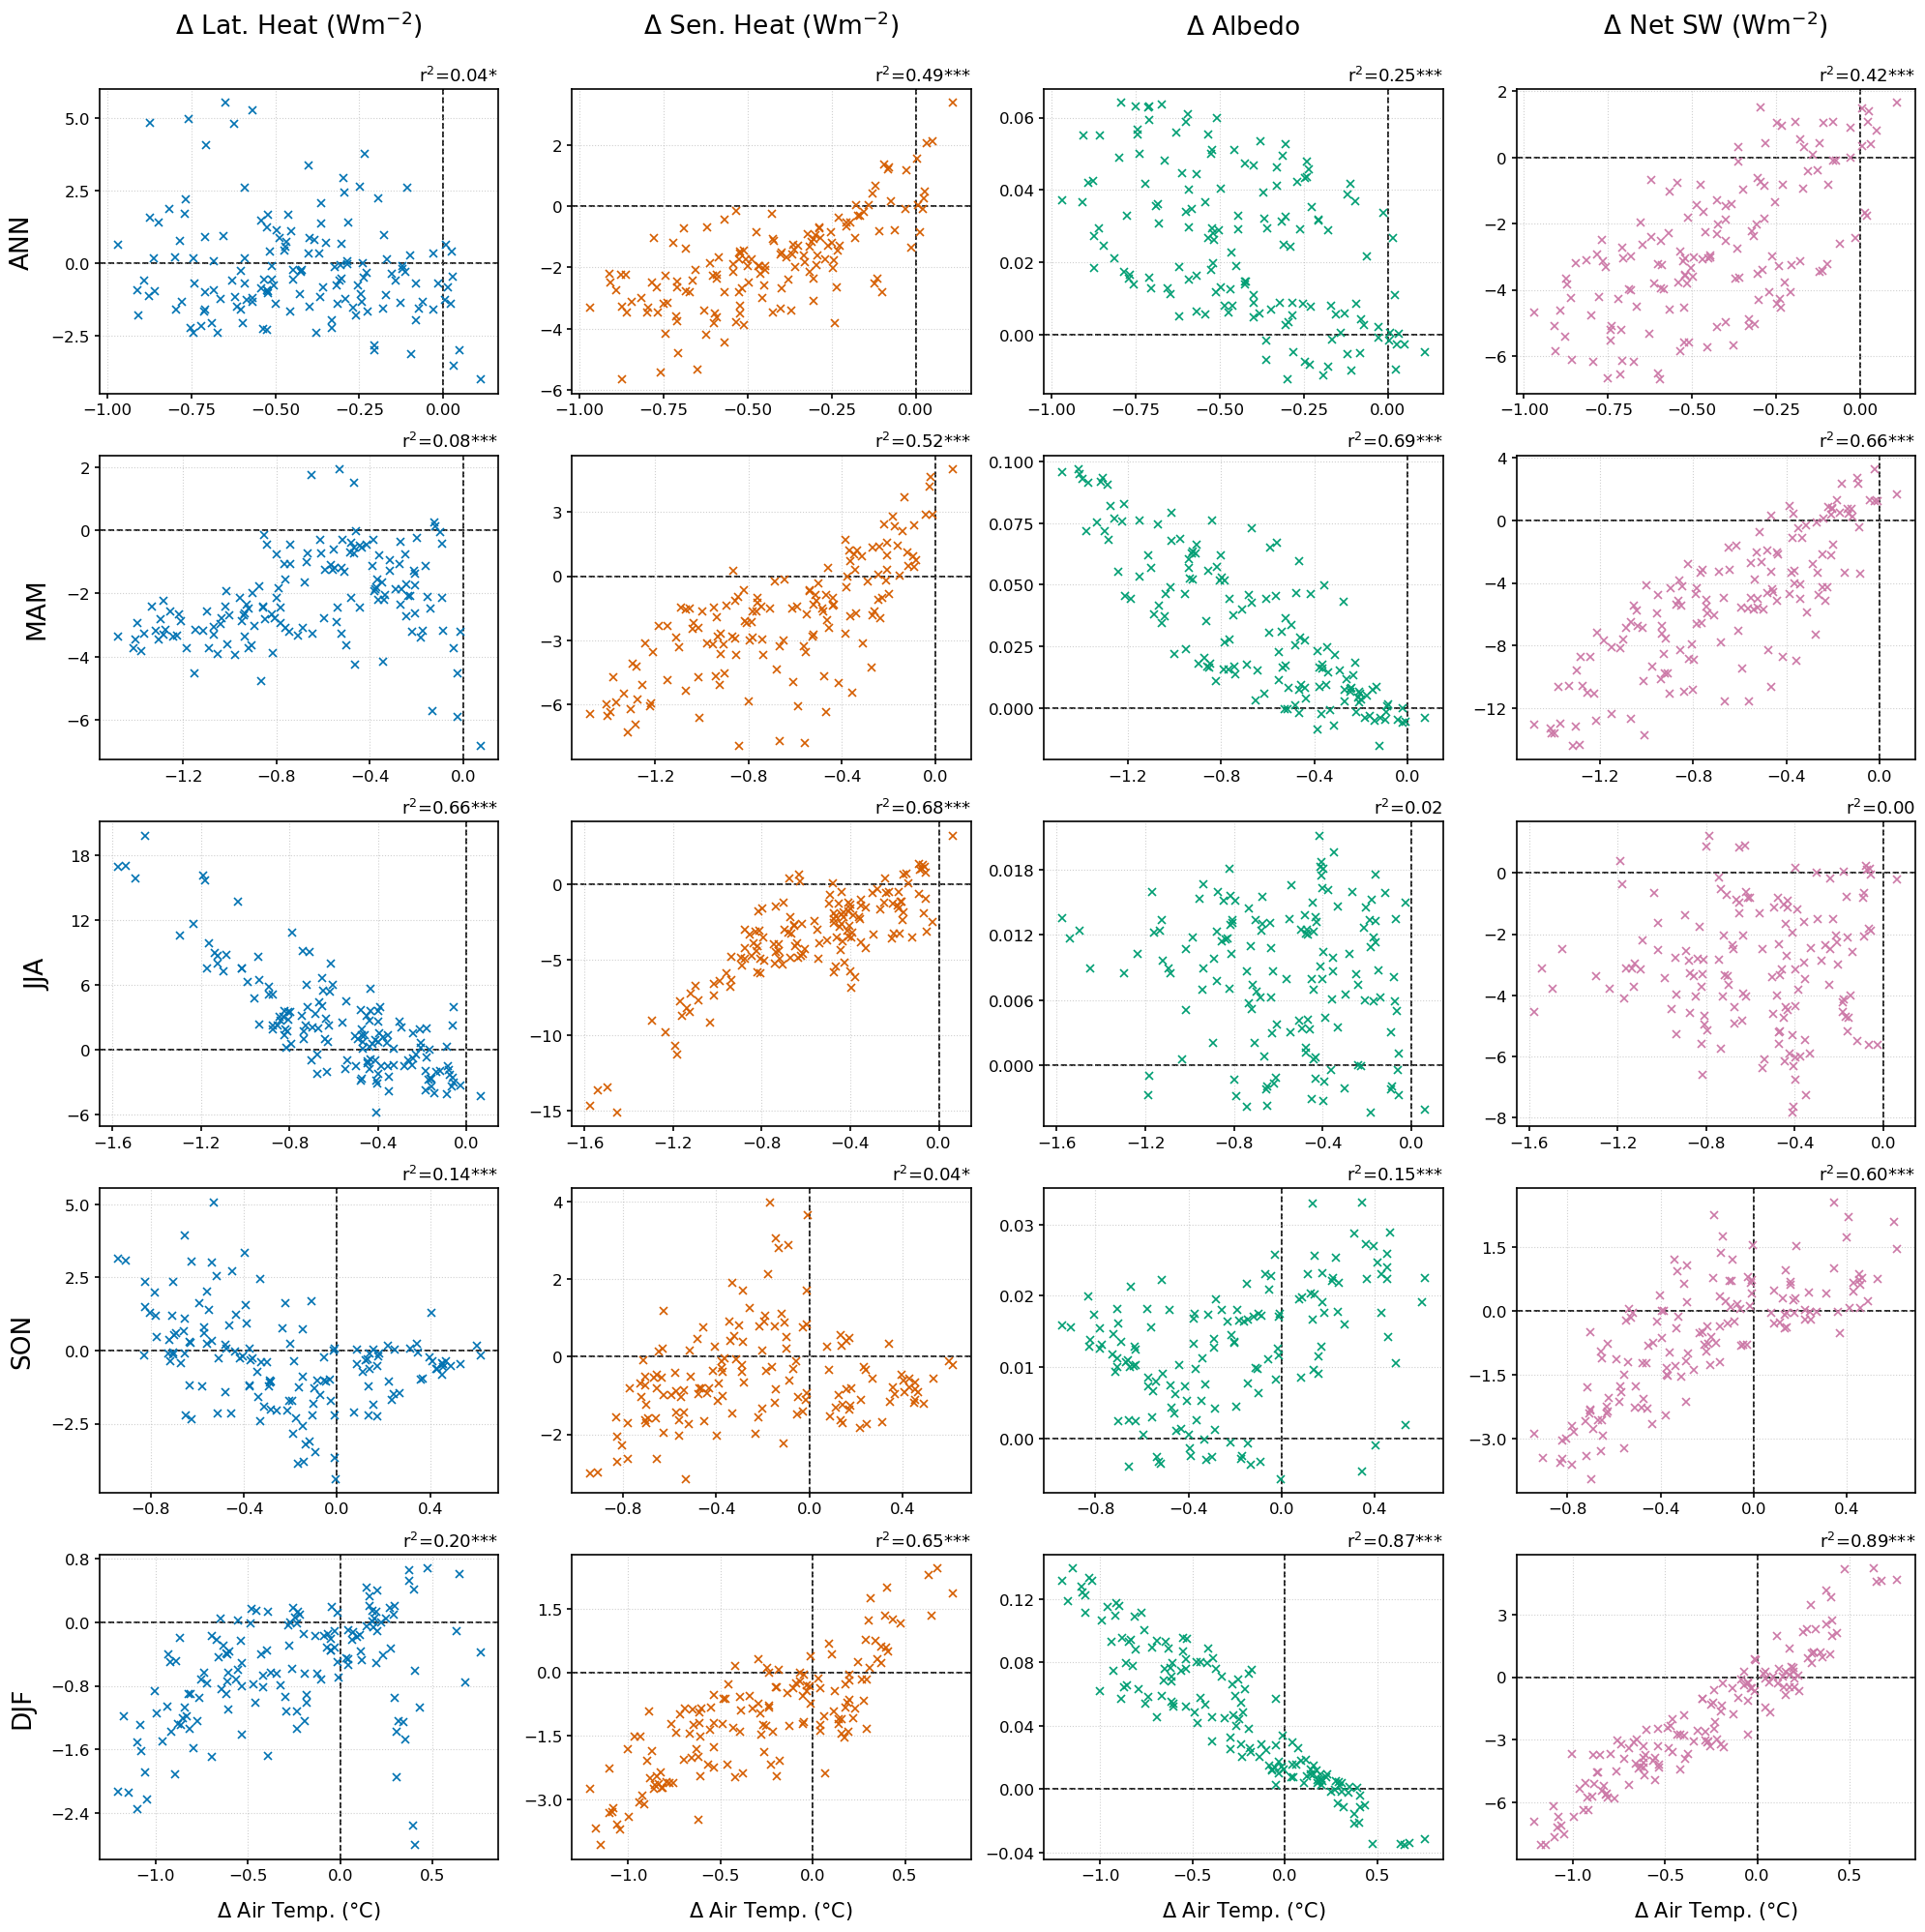

In [ ]:
# ----------------------------------------------------------------------------
# Load Data and set parameters
# ----------------------------------------------------------------------------

MH_MHVEG = um.importUMData(MEANS_DIR / "MH_mhveg_monthly_means.nc")
MH_PIVEG = um.importUMData(MEANS_DIR / "MH_piveg_monthly_means.nc")

GP_MASK  = umplt.umRegionMask("GP", MH_MHVEG.longitude, MH_MHVEG.latitude)
TAS_ANOM = MH_MHVEG["tas"] - MH_PIVEG["tas"]

SEASONS = {"ANN": np.arange(12), "MAM": [2, 3, 4], "JJA": [5, 6, 7],
           "SON": [8, 9, 10],    "DJF": [11, 0, 1]}

# column: (variable, units, colour).  A None variable is derived below.
VARS = {
    "Lat. Heat": ("lat_heat", r"$\mathregular{W m^{-2}}$", "#0072B2"),
    "Sen. Heat": ("sen_heat", r"$\mathregular{W m^{-2}}$", "#D55E00"),
    "Albedo":    (None,        None,                       "#009E73"),
    "Net SW":    ("net_ssw",  r"$\mathregular{W m^{-2}}$", "#CC79A7"),
}

# ----------------------------------------------------------------------------
# Helper Functions
# ----------------------------------------------------------------------------

def albedo(ds):
    """Surface albedo from the net/downward shortwave pair."""
    return 1.0 - ds["net_ssw"] / ds["down_ssw"]


def gp_points(x, y, months):
    """Seasonal means of two fields, flattened to the Great Plains cells.  Cells
    missing in either field are dropped from both, keeping the pair aligned."""
    season = lambda da: (da.where(GP_MASK).isel(time=months).mean("time")
                           .stack(points=("latitude", "longitude")))
    xs, ys = season(x), season(y)
    ok = xs.notnull() & ys.notnull()
    return xs.where(ok, drop=True).values, ys.where(ok, drop=True).values


def regress_label(x, y):
    """r^2 with significance stars, for the panel corner."""
    lr = stats.linregress(x, y)
    stars = ("***" if lr.pvalue < 1e-3 else "**" if lr.pvalue < 1e-2
             else "*" if lr.pvalue < 0.05 else "")
    return rf"$\mathregular{{r^2}}$={lr.rvalue ** 2:.2f}{stars}"

# ----------------------------------------------------------------------------
# Figure: one column per flux term, one row per season
# ----------------------------------------------------------------------------

fig, axs = plt.subplots(len(SEASONS), len(VARS), figsize=(20, 20))

for i, (var, (name, units, colour)) in enumerate(VARS.items()):

    var_anom = (albedo(MH_MHVEG) - albedo(MH_PIVEG) if name is None
                else MH_MHVEG[name] - MH_PIVEG[name])

    for j, (season, idx) in enumerate(SEASONS.items()):
        x, y = gp_points(TAS_ANOM, var_anom, idx)

        ax = axs[j, i]
        ax.plot(x, y, "x", color=colour, ms=6, mew=1.2, zorder=3)
        ax.axhline(0, ls="dashed", color="black", lw=1.2, zorder=1)
        ax.axvline(0, ls="dashed", color="black", lw=1.2, zorder=1)
        ax.grid(True, which="major", ls="dotted", alpha=0.6, zorder=0)
        ax.set_title(regress_label(x, y), loc="right", fontsize=13)

        if j == 0:
            header = rf"$\Delta$ {var} ({units})" if units is not None else rf"$\Delta$ {var}"
            ax.text(0.5, 1.16, header, transform=ax.transAxes,
                    ha="center", va="bottom", fontsize=19)

        if i == 0:
            ax.set_ylabel(season, fontsize=19, labelpad=12)

        if j == len(SEASONS) - 1:
            ax.set_xlabel(r"$\Delta$ Air Temp. (°C)", labelpad=12, fontsize=15)

        ax.spines[["top", "left", "right", "bottom"]].set_linewidth(1.2)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.tick_params(axis="both", width=1.2, labelsize=12)

plt.tight_layout()
plt.show()
